# **Desafio Final**

## **🛠️ Preparación de los Datos**

### **Extracción del Archivo Tratado**

In [52]:
import pandas as pd

In [53]:
datos = pd.read_csv('telecomx_latam_limpio.csv')
datos.head()

,id_cliente,cancelacion,genero,adulto_mayor,tiene_pareja,tiene_dependientes,antiguedad_meses,servicio_telefonico,lineas_multiples,servicio_internet,...,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,facturacion_digital,metodo_pago,cargos_mensuales,cargos_totales,cargos_diarios,rango_costo
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.156710,"(58.45, 78.55]"
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.969313,"(58.45, 78.55]"
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.429586,"(58.45, 78.55]"
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.221914,"(78.55, 98.65]"
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.758353,"(78.55, 98.65]"


### **Eliminación de Columnas Irrelevantes**

In [54]:
#Eliminando columnas que no aportan al modelo

datos_limpios = datos.drop(columns=["id_cliente", 'rango_costo'])

In [ ]:
#Eliminando columnas redundantes
datos_limpios = datos_limpios.drop(columns=["cargos_diarios"])

### **Encoding**

In [56]:
X = datos_limpios.drop(columns=['cancelacion'])
y = datos_limpios['cancelacion']

In [57]:
X.head()

,genero,adulto_mayor,tiene_pareja,tiene_dependientes,antiguedad_meses,servicio_telefonico,lineas_multiples,servicio_internet,seguridad_online,respaldo_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,facturacion_digital,metodo_pago,cargos_mensuales,cargos_totales
0,Female,0,1,1,9,1,No,DSL,No,Yes,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30
1,Male,0,0,0,9,1,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40
2,Male,0,0,0,4,1,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85
3,Male,1,1,0,13,1,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85
4,Female,1,1,0,3,1,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40


In [58]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   genero                  7032 non-null   object 
 1   adulto_mayor            7032 non-null   int64  
 2   tiene_pareja            7032 non-null   int64  
 3   tiene_dependientes      7032 non-null   int64  
 4   antiguedad_meses        7032 non-null   int64  
 5   servicio_telefonico     7032 non-null   int64  
 6   lineas_multiples        7032 non-null   object 
 7   servicio_internet       7032 non-null   object 
 8   seguridad_online        7032 non-null   object 
 9   respaldo_online         7032 non-null   object 
 10  proteccion_dispositivo  7032 non-null   object 
 11  soporte_tecnico         7032 non-null   object 
 12  streaming_tv            7032 non-null   object 
 13  streaming_peliculas     7032 non-null   object 
 14  tipo_contrato           7032 non-null   

In [59]:
categorical_cols = X.select_dtypes(include=['object']).columns
print(categorical_cols)

Index(['genero', 'lineas_multiples', 'servicio_internet', 'seguridad_online',
       'respaldo_online', 'proteccion_dispositivo', 'soporte_tecnico',
       'streaming_tv', 'streaming_peliculas', 'tipo_contrato', 'metodo_pago'],
      dtype='object')


In [60]:
X[categorical_cols].nunique()

genero                    2
lineas_multiples          3
servicio_internet         3
seguridad_online          3
respaldo_online           3
proteccion_dispositivo    3
soporte_tecnico           3
streaming_tv              3
streaming_peliculas       3
tipo_contrato             3
metodo_pago               4
dtype: int64

In [61]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
encoder = OneHotEncoder(sparse_output=False,handle_unknown='ignore', drop='if_binary')

In [62]:

tranformer = make_column_transformer(
    (encoder, categorical_cols),
    remainder='passthrough'
)

In [63]:
X = tranformer.fit_transform(X)


In [64]:
X = pd.DataFrame(data=X, columns=tranformer.get_feature_names_out(), index=datos.index)
X.head()

,onehotencoder__genero_Male,onehotencoder__lineas_multiples_No,onehotencoder__lineas_multiples_No phone service,onehotencoder__lineas_multiples_Yes,onehotencoder__servicio_internet_DSL,onehotencoder__servicio_internet_Fiber optic,onehotencoder__servicio_internet_No,onehotencoder__seguridad_online_No,onehotencoder__seguridad_online_No internet service,onehotencoder__seguridad_online_Yes,...,onehotencoder__metodo_pago_Electronic check,onehotencoder__metodo_pago_Mailed check,remainder__adulto_mayor,remainder__tiene_pareja,remainder__tiene_dependientes,remainder__antiguedad_meses,remainder__servicio_telefonico,remainder__facturacion_digital,remainder__cargos_mensuales,remainder__cargos_totales
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,1.0,9.0,1.0,1.0,65.6,593.30
1,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,9.0,1.0,0.0,59.9,542.40
2,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,4.0,1.0,1.0,73.9,280.85
3,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,1.0,0.0,13.0,1.0,1.0,98.0,1237.85
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,1.0,1.0,0.0,3.0,1.0,1.0,83.9,267.40


### **Verificación de la Proporción de Cancelación (Churn)**

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

In [66]:
datos_limpios.cancelacion.value_counts(normalize=True).round(4) * 100

cancelacion
0    73.42
1    26.58
Name: proportion, dtype: float64

Text(0, 0.5, 'Porcentaje')

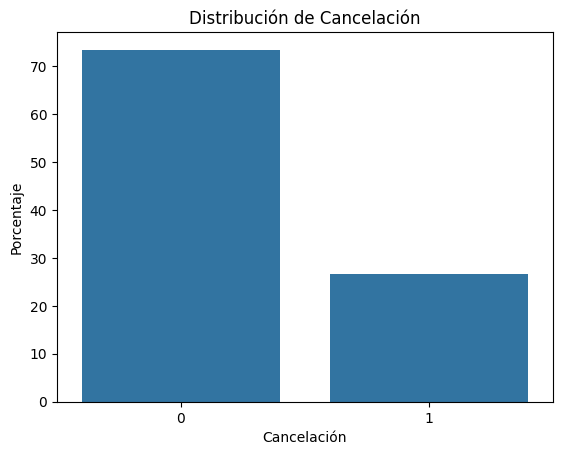

In [67]:
ax = sns.countplot(x='cancelacion', data= datos_limpios, stat='percent')
ax.set_title('Distribución de Cancelación')
ax.set_xlabel('Cancelación')
ax.set_ylabel('Porcentaje')

### **Normalización o Estandarización**

In [68]:
from sklearn.preprocessing import  MinMaxScaler

In [69]:
normalizador = MinMaxScaler()
X_normalizado = normalizador.fit_transform(X)

## **🎯 Correlación y Selección de Variables**


### **Análisis de Correlación**

In [80]:
import numpy as np

In [70]:
datos_transformados = pd.DataFrame(data=X_normalizado, columns=tranformer.get_feature_names_out(), index=datos.index)
datos_transformados['cancelacion'] = y

In [75]:
corr_1 = datos_limpios.corr(numeric_only=True)

In [90]:
corr_transformados_cancelacion = datos_transformados.corr()['cancelacion'].sort_values(ascending=False)

Text(0.5, 1.0, 'Matriz de Correlación - Datos Originales')

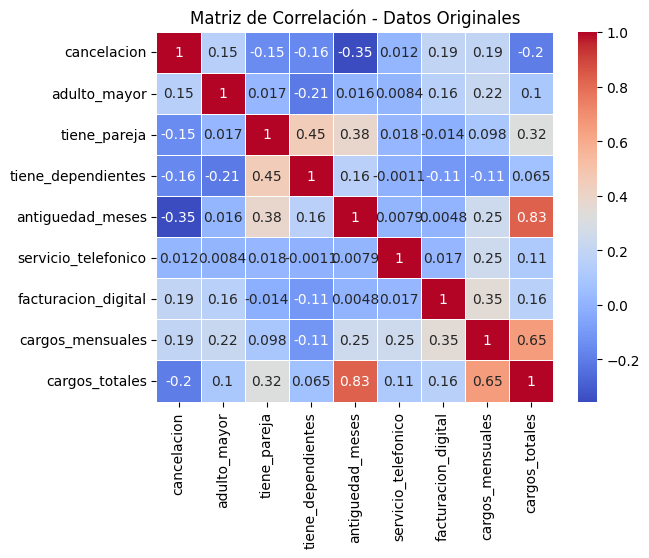

In [77]:
sns.heatmap(corr_1, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación - Datos Originales')

Text(0.5, 1.0, 'Matriz de Correlación - Datos Transformados')

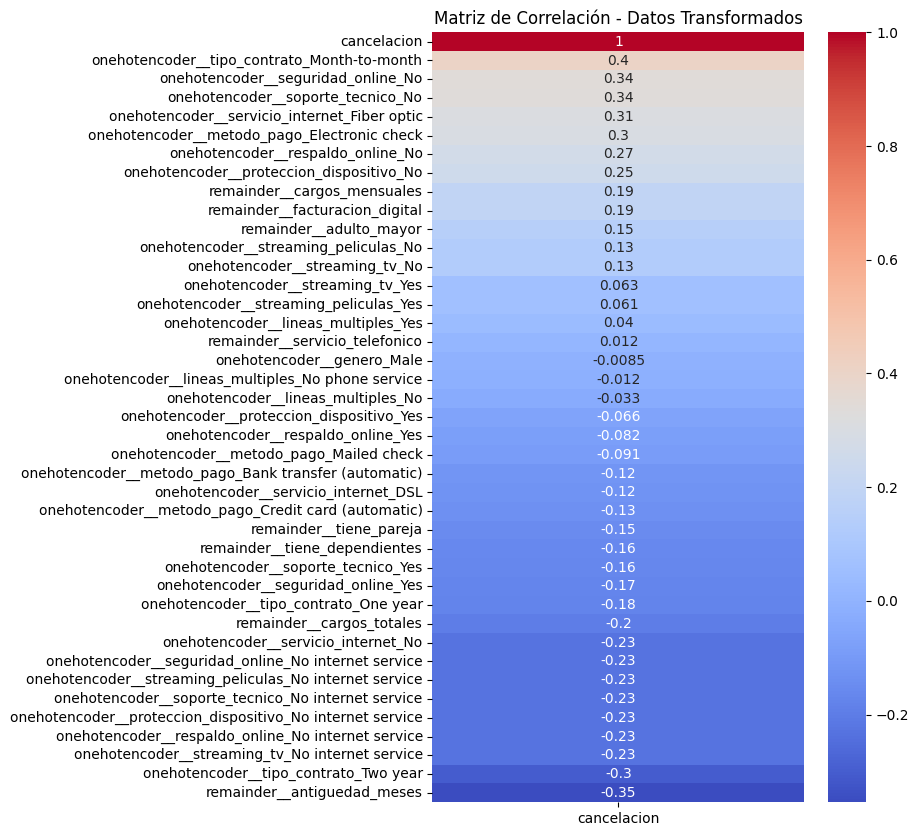

In [95]:
plt.figure(figsize=(6, 10))
sns.heatmap(corr_transformados_cancelacion.to_frame(), annot=True, cmap='coolwarm')

plt.title('Matriz de Correlación - Datos Transformados')